
# GVH Diagonal Cubic — RACC-C.4-real.2.15
## GW150914 H1/L1 — Delay-Recovery Sensitivity & Coverage Decision Audit

**Auteur :** Charlemagne O Laurince  
**Étape :** `RACC-C.4-real.2.15`  
**Nature :** test de décision préenregistré / règle d'arrêt  
**Branche :** RACC-C.4 / GW150914 H1–L1  
**Prédécesseur :** `RACC-C.4-real.2.14-V3`  
**Noyau GVH / chaîne HH modifiés : NON**

---

## Position d'entrée

`real.2.14-V3` a fermé les défauts d'implémentation les plus évidents :

\[
\boxed{
\texttt{UNIT\_SIGN\_GATE=True}
}
\]

\[
\boxed{
\texttt{PHAT\_SCALE\_GATE=True}
}
\]

\[
\boxed{
\texttt{PHAT\_DISTINCT\_FROM\_XCORR=True}
}
\]

\[
\boxed{
\texttt{MATCHED\_FILTER\_UNIT\_GATE=True}
}
\]

mais son verdict final restait :

\[
\boxed{
\texttt{NO-ESTIMATOR-PASSES-QUALIFICATION-GATE}
}
\]

La question de `real.2.15` n'est donc **plus** :

> Quel estimateur donne le plus petit RMSE ?

mais :

\[
\boxed{
\textbf{les sorties contiennent-elles encore une information robuste sur le retard injecté ?}
}
\]

---

# Hypothèse testée

Pour chaque estimateur :

\[
\boxed{
\hat\tau = a + b\,\tau_{\rm inj}
}
\]

avec :

\[
b=\frac{\partial\hat\tau}{\partial\tau_{\rm inj}}.
\]

Interprétation :

- \(b\approx1\) : récupération proportionnelle du retard ;
- \(b\approx0\) : effondrement vers une valeur presque indépendante du retard ;
- \(b<0\) : réponse de signe inversé ;
- \(b>1\) : sur-réponse.

---

# Matrice figée

Aucune optimisation n'est autorisée après lecture des résultats.

\[
\tau_{\rm inj}
\in
\{-10,-7,-4,-1,0,+1,+4,+7,+10\}\ {\rm ms}
\]

\[
\rho_{\rm network}\in\{8,12,20\}
\]

8 fenêtres RAW off-source de 2 s :

\[
t_{\rm rel}
\in
\{-12,-9,-6,-3,+3,+6,+9,+12\}\ {\rm s}.
\]

Les fonctions de preprocessing et les estimateurs sont repris de V3 sans tuning post-hoc.

---

# Estimateurs de décision

Non-oracle :

1. `xcorr`
2. `GCC-PHAT-relative`
3. `phase_slope_unwrap`
4. `phase_circular_2pi_safe`

Contrôle supérieur, **non éligible comme gagnant RACC** :

5. `matched_filter_psd_oracle`

---

# Diagnostics préenregistrés

Pour chaque estimateur :

\[
a,\ b,\ CI_{95\%}^{cluster}(b),\ R^2,
\]

\[
\rho_{\rm Spearman},
\qquad
C=\frac{N_{\rm finite}}{N_{\rm total}},
\]

\[
\sigma_{\rm robust}(\hat\tau\mid\tau_{\rm inj}),
\]

pentes séparées par :

- SNR réseau ;
- fenêtre de bruit ;
- SNR individuel H1/L1.

Les NaN comptent comme **échecs de récupération** dans la couverture et les taux de succès.

L'incertitude sur \(b\) est estimée par **bootstrap par fenêtre off-source**, afin de ne pas traiter artificiellement les injections partageant le même bruit comme totalement indépendantes.

---

# Gate de récupération préenregistré

Ces seuils sont des **critères décisionnels de ce protocole**, pas des constantes universelles :

\[
0.75\le b\le1.25,
\]

\[
CI_{95\%,low}(b)>0.50,
\]

\[
C\ge0.90,
\]

\[
R^2\ge0.50,
\]

\[
\rho_{\rm Spearman}\ge0.70,
\]

et :

- pente \(b_{\rho}\ge0.50\) pour chacun des trois SNR réseau ;
- au moins 6 fenêtres sur 8 avec une pente locale \(b_{\rm window}>0.50\).

Un estimateur doit satisfaire **tous** ces critères pour être déclaré `RECOVERY_SUPPORTED`.

---

# Règle d'arrêt

Si aucun estimateur non-oracle ne passe :

\[
\boxed{
\texttt{GW150914-H1L1-TIMING-BRANCH-CLOSED-NO-ROBUST-RECOVERY}
}
\]

La branche timing H1/L1 actuelle est alors fermée négativement.

Aucune V4/V5/V6 destinée à faire passer le gate n'est autorisée dans cette branche sans nouveau protocole indépendant explicitement justifié.

Si au moins un estimateur passe :

\[
\boxed{
\texttt{DELAY-RECOVERY-SENSITIVITY-SUPPORTED}
}
\]

la seule suite autorisée est une **validation indépendante avec pipeline gelé**.

Même dans ce cas :

\[
\boxed{
\texttt{TIMING\_VALIDATED=False},
\quad
D_T^{ref}=\texttt{NOT-AUTHORIZED},
\quad
\texttt{REAL3\_AUTHORIZED=False}.
}
\]


In [1]:

# ============================================================
# 0 — Protocol preregistration hash
# ============================================================
import json, hashlib

PREREG_PROTOCOL = {
    "step": "RACC-C.4-real.2.15",
    "question": "Does estimated lag retain robust information about injected lag?",
    "delay_grid_ms": [-10,-7,-4,-1,0,1,4,7,10],
    "network_snr_targets": [8.0,12.0,20.0],
    "offsource_centers_s": [-12.0,-9.0,-6.0,-3.0,3.0,6.0,9.0,12.0],
    "non_oracle_estimators": [
        "xcorr",
        "GCC-PHAT-relative",
        "phase_slope_unwrap",
        "phase_circular_2pi_safe"
    ],
    "oracle_control": "matched_filter_psd_oracle",
    "decision_thresholds": {
        "slope_min": 0.75,
        "slope_max": 1.25,
        "cluster_bootstrap_ci_low_min": 0.50,
        "coverage_min": 0.90,
        "r2_min": 0.50,
        "spearman_min": 0.70,
        "each_snr_slope_min": 0.50,
        "window_slope_min": 0.50,
        "min_windows_passing": 6
    },
    "nan_policy": "NaN counts as recovery failure for coverage/success",
    "bootstrap_unit": "offsource_noise_window",
    "n_bootstrap": 4000,
    "stop_rule": "close GW150914 H1/L1 timing branch if no non-oracle estimator passes all criteria",
    "physical_gates_remain_closed": True
}

PREREG_JSON = json.dumps(PREREG_PROTOCOL, sort_keys=True)
PREREG_SHA256 = hashlib.sha256(PREREG_JSON.encode()).hexdigest()

print(json.dumps(PREREG_PROTOCOL, indent=2))
print("PREREG_SHA256 =", PREREG_SHA256)


{
  "step": "RACC-C.4-real.2.15",
  "question": "Does estimated lag retain robust information about injected lag?",
  "delay_grid_ms": [
    -10,
    -7,
    -4,
    -1,
    0,
    1,
    4,
    7,
    10
  ],
  "network_snr_targets": [
    8.0,
    12.0,
    20.0
  ],
  "offsource_centers_s": [
    -12.0,
    -9.0,
    -6.0,
    -3.0,
    3.0,
    6.0,
    9.0,
    12.0
  ],
  "non_oracle_estimators": [
    "xcorr",
    "GCC-PHAT-relative",
    "phase_slope_unwrap",
    "phase_circular_2pi_safe"
  ],
  "oracle_control": "matched_filter_psd_oracle",
  "decision_thresholds": {
    "slope_min": 0.75,
    "slope_max": 1.25,
    "cluster_bootstrap_ci_low_min": 0.5,
    "coverage_min": 0.9,
    "r2_min": 0.5,
    "spearman_min": 0.7,
    "each_snr_slope_min": 0.5,
    "window_slope_min": 0.5,
    "min_windows_passing": 6
  },
  "nan_policy": "NaN counts as recovery failure for coverage/success",
  "bootstrap_unit": "offsource_noise_window",
  "n_bootstrap": 4000,
  "stop_rule": "close GW150

## 1 — Environnement logiciel repris de V3

In [2]:

import os, sys, subprocess, importlib, json, math
from pathlib import Path

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

try:
    import lal
    import lalsimulation as lalsim
    import lalframe
except Exception:
    pip_install("lalsuite")
    importlib.invalidate_caches()
    import lal
    import lalsimulation as lalsim
    import lalframe

try:
    import gwpy
except Exception:
    pip_install("gwpy")
    importlib.invalidate_caches()
    import gwpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from gwpy.timeseries import TimeSeries

RNG = np.random.default_rng(21403)

print("gwpy:", gwpy.__version__)
print("lalsimulation:", hasattr(lalsim, "SimInspiralChooseFDWaveform"))


/tmp/ipykernel_859/3855724781.py:14: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


gwpy: 4.0.1
lalsimulation: True


## 2 — Chargement H1/L1

In [3]:

GPS_EVENT = 1126259462.0
FS_EXPECTED = 4096.0

def discover(pattern):
    roots = [Path.cwd(), Path("/content"), Path("/content/drive/MyDrive"), Path("/mnt/data")]
    hits = []
    for root in roots:
        if not root.exists():
            continue
        for d in [root, root/"data"/"GW150914", root/"gvh_diagonal_cubic"/"data"/"GW150914"]:
            if d.exists():
                hits += list(d.glob(pattern))
    return hits[0].resolve() if hits else None

H1 = discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
L1 = discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")

if H1 is None or L1 is None:
    try:
        from google.colab import files
        files.upload()
        H1 = discover("H-H1_LOSC_4_V2-1126259446-32*.gwf")
        L1 = discover("L-L1_LOSC_4_V2-1126259446-32*.gwf")
    except Exception:
        pass

if H1 is None or L1 is None:
    raise FileNotFoundError("Fichiers H1/L1 GW150914 introuvables.")

h1_ts = TimeSeries.read(str(H1), channel="H1:LOSC-STRAIN")
l1_ts = TimeSeries.read(str(L1), channel="L1:LOSC-STRAIN")

h1 = np.asarray(h1_ts.value, float)
l1 = np.asarray(l1_ts.value, float)

fs = float(h1_ts.sample_rate.value)
gps0 = float(h1_ts.t0.value)
t_rel = gps0 + np.arange(len(h1))/fs - GPS_EVENT

assert np.isclose(fs, FS_EXPECTED)
assert len(h1) == len(l1) == 131072
assert np.isfinite(h1).all() and np.isfinite(l1).all()

print(H1.name)
print(L1.name)
print("N =", len(h1), "fs =", fs)


Saving L-L1_LOSC_4_V2-1126259446-32.gwf to L-L1_LOSC_4_V2-1126259446-32.gwf
Saving H-H1_LOSC_4_V2-1126259446-32 2.gwf to H-H1_LOSC_4_V2-1126259446-32 2.gwf
H-H1_LOSC_4_V2-1126259446-32 2.gwf
L-L1_LOSC_4_V2-1126259446-32.gwf
N = 131072 fs = 4096.0


## 3 — Prétraitement figé \(P\)

In [4]:

def center(x):
    x = np.asarray(x, float)
    return x - np.mean(x)

def preprocessing_P(x, lo=35.0, hi=350.0):
    sos = signal.butter(4, [lo, hi], btype="bandpass", fs=fs, output="sos")
    y = signal.sosfiltfilt(sos, center(x))

    for f0 in [60, 120, 180, 240, 300]:
        b, a = signal.iirnotch(f0, Q=30, fs=fs)
        y = signal.filtfilt(b, a, y)

    return y


## 4 — Waveform GR IMRPhenomD

template samples: 8192
duration [s]: 2.0


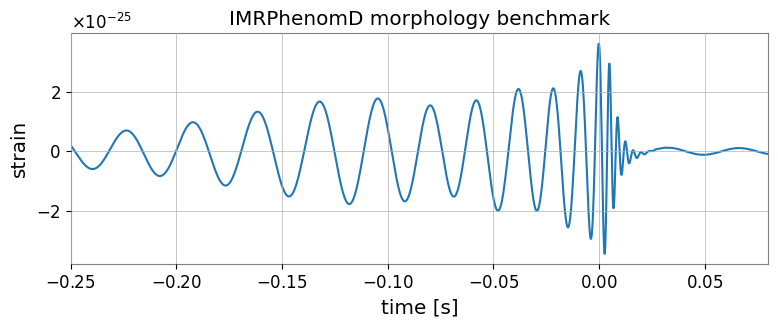

In [5]:

MSUN_SI = lal.MSUN_SI
PC_SI = lal.PC_SI

def make_imrphenomd_template(
    fs=4096.0,
    duration=2.0,
    m1_msun=36.0,
    m2_msun=29.0,
    distance_mpc=410.0,
    inclination=0.7,
    f_min=30.0
):
    n = int(2**np.ceil(np.log2(duration*fs)))
    duration = n/fs
    delta_f = 1.0/duration
    f_max = fs/2

    hp, hc = lalsim.SimInspiralChooseFDWaveform(
        m1_msun*MSUN_SI, m2_msun*MSUN_SI,
        0.0, 0.0, 0.0,
        0.0, 0.0, 0.0,
        distance_mpc*1e6*PC_SI,
        inclination,
        0.0, 0.0,
        0.0, 0.0,
        delta_f,
        f_min,
        f_max,
        f_min,
        None,
        lalsim.IMRPhenomD
    )

    H = np.asarray(hp.data.data, complex)
    target_bins = n//2 + 1

    if len(H) < target_bins:
        H = np.pad(H, (0, target_bins-len(H)))
    elif len(H) > target_bins:
        H = H[:target_bins]

    h = np.fft.irfft(H, n=n)
    peak = int(np.argmax(np.abs(h)))
    h = np.roll(h, n//2 - peak)
    h *= signal.windows.tukey(n, alpha=0.10)
    h = center(h)

    return h

template_phys = make_imrphenomd_template()
NSEG = len(template_phys)
SEG_DUR = NSEG/fs

print("template samples:", NSEG)
print("duration [s]:", SEG_DUR)

tt = (np.arange(NSEG)-NSEG//2)/fs
plt.figure(figsize=(9,3))
plt.plot(tt, template_phys)
plt.xlim(-0.25, 0.08)
plt.xlabel("time [s]")
plt.ylabel("strain")
plt.title("IMRPhenomD morphology benchmark")
plt.grid(True)
plt.show()


## 5 — Convention de retard fractionnaire

In [6]:

def fractional_delay(x, delay_s):
    """
    Convention:
        y(t) = x(t-delay_s)

    Positive delay => y arrives later.
    """
    x = np.asarray(x, float)
    n = len(x)

    pad = n
    xp = np.pad(x, (pad, pad))
    N = len(xp)

    f = np.fft.rfftfreq(N, 1/fs)
    X = np.fft.rfft(xp)
    Y = X*np.exp(-1j*2*np.pi*f*delay_s)

    yp = np.fft.irfft(Y, n=N)
    return yp[pad:pad+n]

imp = np.zeros(4096)
imp[2048] = 1.0

for tau_ms in [-10,-4,-1,1,4,10]:
    y = fractional_delay(imp, tau_ms*1e-3)
    measured = (np.argmax(y)-np.argmax(imp))/fs*1e3
    print(tau_ms, "ms ->", measured, "ms")
    assert abs(measured-tau_ms) <= (1/fs*1e3 + 1e-9)


-10 ms -> -10.009765625 ms
-4 ms -> -3.90625 ms
-1 ms -> -0.9765625 ms
1 ms -> 0.9765625 ms
4 ms -> 3.90625 ms
10 ms -> 10.009765625 ms


## 6 — Estimateurs temporels et de phase figés

In [7]:

MAX_LAG = 0.012

def parab(a, b, c):
    d = a - 2*b + c
    return 0.0 if d == 0 or not np.isfinite(d) else 0.5*(a-c)/d

def xcorr_lag(a, b):
    """
    Returns tau for b(t)=a(t-tau).
    """
    a = center(a)
    b = center(b)

    c = signal.correlate(a, b, mode="full", method="fft")
    lag = signal.correlation_lags(len(a), len(b), mode="full")/fs

    m = np.abs(lag) <= MAX_LAG
    cc = c[m]
    ll = lag[m]

    s = np.abs(cc)
    i = int(np.argmax(s))
    frac = parab(s[i-1], s[i], s[i+1]) if 0 < i < len(s)-1 else 0.0

    return float(-(ll[i] + frac/fs))

def phase_objects(a, b, nper=512):
    """
    scipy.signal.csd(a,b) = conj(A) B.
    If b(t)=a(t-tau), phase ≈ -2π f tau.
    """
    f, Pab = signal.csd(
        a, b, fs=fs,
        nperseg=nper,
        noverlap=nper//2,
        window="hann"
    )

    _, coh = signal.coherence(
        a, b, fs=fs,
        nperseg=nper,
        noverlap=nper//2,
        window="hann"
    )

    ph = np.angle(Pab)

    m = (
        (f >= 40)
        & (f <= 300)
        & np.isfinite(ph)
        & np.isfinite(coh)
    )

    return f[m], ph[m], coh[m]

def phase_slope_unwrap(a, b):
    f, ph, coh = phase_objects(a, b)

    m = coh >= 0.10
    f = f[m]
    ph = ph[m]
    w = coh[m]

    if len(f) < 5:
        return np.nan

    pu = np.unwrap(ph)

    A = np.c_[f, np.ones_like(f)]
    W = np.sqrt(np.clip(w, 1e-12, None))

    beta, *_ = np.linalg.lstsq(
        A*W[:,None],
        pu*W,
        rcond=None
    )

    return float(-beta[0]/(2*np.pi))

def phase_circular_2pi_safe(a, b):
    f, ph, coh = phase_objects(a, b)

    m = coh >= 0.10
    f = f[m]
    ph = ph[m]
    w = coh[m]

    if len(f) < 5:
        return np.nan

    grid = np.linspace(-MAX_LAG, MAX_LAG, 2401)
    z = np.exp(1j*ph)

    score = np.empty_like(grid)

    for i, tau in enumerate(grid):
        score[i] = np.abs(
            np.sum(
                w*z*np.exp(+1j*2*np.pi*f*tau)
            )
        )

    j = int(np.argmax(score))

    frac = (
        parab(score[j-1], score[j], score[j+1])
        if 0 < j < len(score)-1
        else 0.0
    )

    dtau = grid[1]-grid[0]

    return float(grid[j] + frac*dtau)


## 7 — GCC-PHAT relatif figé

In [8]:

PHAT_REL_EPS = 1e-12

def phat_lag_relative(a, b, return_diagnostics=False):
    """
    GCC-PHAT V3 with relative regularization.

    G = A * conj(B)

    The absolute epsilon used previously is forbidden here.
    """
    a = center(a)
    b = center(b)

    n = int(2**np.ceil(np.log2(len(a)+len(b))))

    A = np.fft.rfft(a, n=n)
    B = np.fft.rfft(b, n=n)

    G = A*np.conj(B)
    mag = np.abs(G)

    max_mag = float(np.max(mag))
    eps_rel = PHAT_REL_EPS*max_mag if max_mag > 0 else np.finfo(float).tiny

    R = G/(mag + eps_rel)

    cc = np.fft.irfft(R, n=n)
    cc = np.concatenate((cc[-n//2:], cc[:n//2]))

    lag = np.arange(-n//2, n//2)/fs

    m = np.abs(lag) <= MAX_LAG
    ss = np.abs(cc[m])
    ll = lag[m]

    i = int(np.argmax(ss))
    frac = parab(ss[i-1], ss[i], ss[i+1]) if 0 < i < len(ss)-1 else 0.0

    tau = float(-(ll[i] + frac/fs))

    active = mag >= (1e-6*max_mag) if max_mag > 0 else np.zeros_like(mag, dtype=bool)

    if np.any(active):
        rel_reg_ratio = float(np.median(eps_rel/(mag[active] + eps_rel)))
        median_phat_norm = float(np.median(mag[active]/(mag[active] + eps_rel)))
    else:
        rel_reg_ratio = np.nan
        median_phat_norm = np.nan

    diagnostics = {
        "max_abs_G": max_mag,
        "epsilon_relative": float(eps_rel),
        "median_regularization_fraction_active_bins": rel_reg_ratio,
        "median_phat_normalization_active_bins": median_phat_norm,
        "n_active_bins": int(np.sum(active))
    }

    if return_diagnostics:
        return tau, diagnostics

    return tau


## 8 — Fenêtres RAW off-source

In [9]:

CENTERS = [-12.0,-9.0,-6.0,-3.0,3.0,6.0,9.0,12.0]

def segment_around_raw(x, center_s, n=NSEG):
    c = int(np.argmin(np.abs(t_rel-center_s)))
    a = c - n//2
    b = a + n

    if a < 0 or b > len(x):
        return None

    return np.array(x[a:b], float)

noise_pairs = []

for c in CENTERS:
    nh = segment_around_raw(h1, c)
    nl = segment_around_raw(l1, c)

    if (
        nh is not None
        and nl is not None
        and len(nh) == NSEG
        and len(nl) == NSEG
    ):
        noise_pairs.append((c,nh,nl))

print("RAW off-source pairs:", len(noise_pairs))
assert len(noise_pairs) >= 6


RAW off-source pairs: 8


## 9 — PSD et SNR optimal

In [10]:

SNR_FMIN = 35.0
SNR_FMAX = 350.0

def estimate_noise_psd(noise_raw):
    nper = min(2048, len(noise_raw))

    f, P = signal.welch(
        center(noise_raw),
        fs=fs,
        nperseg=nper,
        noverlap=nper//2,
        window="hann",
        detrend="constant",
        scaling="density",
        average="median"
    )

    floor = np.finfo(float).tiny
    return f, np.maximum(P, floor)

def optimal_snr_timeseries(h, f_psd, P):
    h = np.asarray(h,float)

    n = len(h)
    dt = 1/fs

    f = np.fft.rfftfreq(n,dt)
    Hc = dt*np.fft.rfft(h)

    Pi = np.interp(
        f, f_psd, P,
        left=P[0],
        right=P[-1]
    )

    df = fs/n

    m = (
        (f >= SNR_FMIN)
        & (f <= SNR_FMAX)
        & np.isfinite(Pi)
        & (Pi > 0)
    )

    rho2 = 4*np.sum(
        np.abs(Hc[m])**2/Pi[m]
    )*df

    return float(np.sqrt(max(rho2,0.0)))


## 10 — Calibration du SNR réseau

In [11]:

NETWORK_SNRS = [8.0,12.0,20.0]
DELAYS_MS = np.array([-10,-7,-4,-1,0,1,4,7,10], float)

def calibrate_network_amplitude(
    template,
    noise_h_raw,
    noise_l_raw,
    response_ratio,
    target_rho
):
    fh, Ph = estimate_noise_psd(noise_h_raw)
    fl, Pl = estimate_noise_psd(noise_l_raw)

    rho_h_unit = optimal_snr_timeseries(
        template, fh, Ph
    )

    rho_l_unit = optimal_snr_timeseries(
        template, fl, Pl
    )

    denom = np.sqrt(
        rho_h_unit**2
        +
        (abs(response_ratio)*rho_l_unit)**2
    )

    if not np.isfinite(denom) or denom <= 0:
        raise ValueError(
            "Invalid SNR calibration denominator."
        )

    A = target_rho/denom

    achieved = np.sqrt(
        (A*rho_h_unit)**2
        +
        (A*abs(response_ratio)*rho_l_unit)**2
    )

    return (
        float(A),
        float(achieved),
        float(rho_h_unit),
        float(rho_l_unit)
    )


## 11 — Matched-filter PSD oracle figé

In [12]:

MF_SEARCH_HALF_WIDTH = 0.030

def psd_whiten_for_matched_filter(x, f_psd, P):
    """
    Frequency-domain inverse-sqrt-PSD weighting.
    Overall normalization is irrelevant for lag location.
    """
    x = center(np.asarray(x,float))

    n = len(x)
    f = np.fft.rfftfreq(n,1/fs)

    X = np.fft.rfft(x)

    Pi = np.interp(
        f, f_psd, P,
        left=P[0],
        right=P[-1]
    )

    mask = (
        (f >= SNR_FMIN)
        & (f <= SNR_FMAX)
        & np.isfinite(Pi)
        & (Pi > 0)
    )

    W = np.zeros_like(X, dtype=complex)
    W[mask] = X[mask]/np.sqrt(Pi[mask])

    return np.fft.irfft(W,n=n)

def matched_filter_arrival_shift(
    data_raw,
    template_raw,
    f_psd,
    P,
    search_half_width=MF_SEARCH_HALF_WIDTH
):
    """
    Return shift of data signal relative to centered template.
    Positive => signal appears later than template.
    """
    dw = psd_whiten_for_matched_filter(
        data_raw, f_psd, P
    )

    tw = psd_whiten_for_matched_filter(
        template_raw, f_psd, P
    )

    c = signal.correlate(
        dw, tw,
        mode="full",
        method="fft"
    )

    lags = signal.correlation_lags(
        len(dw), len(tw),
        mode="full"
    )/fs

    m = np.abs(lags) <= search_half_width

    cc = np.abs(c[m])
    ll = lags[m]

    i = int(np.argmax(cc))

    frac = (
        parab(
            cc[i-1],
            cc[i],
            cc[i+1]
        )
        if 0 < i < len(cc)-1
        else 0.0
    )

    return float(
        ll[i] + frac/fs
    )

def matched_filter_psd_oracle_relative_lag(
    H_raw,
    L_raw,
    template_h_raw,
    template_l_reference_raw,
    fh, Ph,
    fl, Pl
):
    """
    Exact injection-template oracle.

    H arrival shift is measured relative to H template.
    L arrival shift is measured relative to the *undelayed*
    L morphology/reference template.

    Their difference estimates L-H delay.
    """
    shift_h = matched_filter_arrival_shift(
        H_raw,
        template_h_raw,
        fh, Ph
    )

    shift_l = matched_filter_arrival_shift(
        L_raw,
        template_l_reference_raw,
        fl, Pl
    )

    return float(
        shift_l-shift_h
    )



## 12 — Sanity gates hérités

`real.2.15` ne retune pas les estimateurs, mais vérifie que les conventions élémentaires qui étaient fermées dans V3 restent intactes avant le test de décision.


In [13]:

# Broadband sign/convention control
gate_rng = np.random.default_rng(21515)

u = gate_rng.normal(size=NSEG)
sos_gate = signal.butter(
    4, [40,300],
    btype="bandpass",
    fs=fs,
    output="sos"
)
u = signal.sosfiltfilt(sos_gate, u)
u *= signal.windows.tukey(len(u), alpha=.10)

UNIT_DELAYS_MS = [-10,-4,-1,1,4,10]
unit_rows = []

for tau_ms in UNIT_DELAYS_MS:
    v = fractional_delay(u, tau_ms*1e-3)

    vals = {
        "xcorr": xcorr_lag(u,v)*1e3,
        "GCC-PHAT-relative": phat_lag_relative(u,v)*1e3,
        "phase_slope_unwrap": phase_slope_unwrap(u,v)*1e3,
        "phase_circular_2pi_safe": phase_circular_2pi_safe(u,v)*1e3
    }

    for est, val in vals.items():
        unit_rows.append({
            "tau_true_ms": tau_ms,
            "estimator": est,
            "tau_est_ms": val,
            "abs_error_ms": abs(val-tau_ms)
        })

unit_df = pd.DataFrame(unit_rows)
UNIT_MAX_ERROR_MS = unit_df.groupby("estimator").abs_error_ms.max()
UNIT_SIGN_GATE = bool((UNIT_MAX_ERROR_MS <= 0.35).all())

# PHAT scale control
v4 = fractional_delay(u, 0.004)
tau_phat_test, phat_diag = phat_lag_relative(u, v4, return_diagnostics=True)

PHAT_SCALE_GATE = bool(
    abs(tau_phat_test*1e3 - 4.0) <= 0.35
    and phat_diag["n_active_bins"] > 10
    and phat_diag["median_regularization_fraction_active_bins"] < 1e-4
    and phat_diag["median_phat_normalization_active_bins"] > 0.999
)

# Matched-filter unit control, with independent PSD noise only
mf_rng = np.random.default_rng(21516)
noise_psd_h = mf_rng.normal(0.0, 1.0, size=NSEG)
noise_psd_l = mf_rng.normal(0.0, 1.0, size=NSEG)
f_h_test, P_h_test = estimate_noise_psd(noise_psd_h)
f_l_test, P_l_test = estimate_noise_psd(noise_psd_l)

base = template_phys / (np.std(template_phys)+np.finfo(float).eps)
mf_unit_rows = []

for tau_ms in UNIT_DELAYS_MS:
    Ht = base.copy()
    Lt = fractional_delay(base, tau_ms*1e-3)

    est_ms = matched_filter_psd_oracle_relative_lag(
        Ht, Lt,
        base, base,
        f_h_test, P_h_test,
        f_l_test, P_l_test
    )*1e3

    mf_unit_rows.append({
        "tau_true_ms": tau_ms,
        "tau_est_ms": est_ms,
        "abs_error_ms": abs(est_ms-tau_ms)
    })

mf_unit_df = pd.DataFrame(mf_unit_rows)
MATCHED_FILTER_UNIT_GATE = bool(mf_unit_df.abs_error_ms.max() <= 0.35)

display(unit_df)
display(mf_unit_df)

print("UNIT_SIGN_GATE =", UNIT_SIGN_GATE)
print("PHAT_SCALE_GATE =", PHAT_SCALE_GATE)
print("MATCHED_FILTER_UNIT_GATE =", MATCHED_FILTER_UNIT_GATE)

if not (UNIT_SIGN_GATE and PHAT_SCALE_GATE and MATCHED_FILTER_UNIT_GATE):
    raise RuntimeError(
        "Inherited implementation sanity gate failed. "
        "Do not execute the real.2.15 decision matrix."
    )


,tau_true_ms,estimator,tau_est_ms,abs_error_ms
0,-10,xcorr,-10.000099,0.000099
1,-10,GCC-PHAT-relative,-10.005099,0.005099
2,-10,phase_slope_unwrap,-9.941702,0.058298
3,-10,phase_circular_2pi_safe,-9.941798,0.058202
4,-4,xcorr,-3.999604,0.000396
5,-4,GCC-PHAT-relative,-3.996563,0.003437
6,-4,phase_slope_unwrap,-3.976987,0.023013
7,-4,phase_circular_2pi_safe,-3.976993,0.023007
8,-1,xcorr,-0.999769,0.000231
9,-1,GCC-PHAT-relative,-0.996414,0.003586


,tau_true_ms,tau_est_ms,abs_error_ms
0,-10,-10.000055,0.000055
1,-4,-3.999735,0.000265
2,-1,-0.999849,0.000151
3,1,0.999852,0.000148
4,4,3.999725,0.000275
5,10,10.000047,0.000047


UNIT_SIGN_GATE = True
PHAT_SCALE_GATE = True
MATCHED_FILTER_UNIT_GATE = True



## 13 — Matrice d'injection figée

Le générateur aléatoire est remis au seed de V3 (`21403`) afin de reproduire les mêmes tirages de rapport de réponse et de polarité par fenêtre/SNR.

Aucune nouvelle optimisation d'estimateur ou de preprocessing n'est effectuée.


In [14]:

# IMPORTANT: same seed as V3 matrix construction
RNG = np.random.default_rng(21403)

NETWORK_SNRS = [8.0,12.0,20.0]
DELAYS_MS = np.array([-10,-7,-4,-1,0,1,4,7,10], float)

rows = []

for center_s, nh_raw, nl_raw in noise_pairs:

    fh, Ph = estimate_noise_psd(nh_raw)
    fl, Pl = estimate_noise_psd(nl_raw)

    for rho_target in NETWORK_SNRS:

        response_ratio = float(RNG.uniform(0.65,1.35))
        polarity = float(RNG.choice([-1.0,1.0]))

        A, rho_achieved, rho_h_unit, rho_l_unit = calibrate_network_amplitude(
            template_phys,
            nh_raw,
            nl_raw,
            response_ratio,
            rho_target
        )

        h_template_raw = A*template_phys
        l_template_reference_raw = polarity*response_ratio*A*template_phys

        for delay_ms in DELAYS_MS:

            tau = delay_ms*1e-3

            h_inj = h_template_raw
            l_inj = (
                polarity
                * response_ratio
                * A
                * fractional_delay(template_phys, tau)
            )

            H_raw_injected = nh_raw + h_inj
            L_raw_injected = nl_raw + l_inj

            H = preprocessing_P(H_raw_injected)
            L = preprocessing_P(L_raw_injected)

            estimates = {
                "xcorr": xcorr_lag(H,L),
                "GCC-PHAT-relative": phat_lag_relative(H,L),
                "phase_slope_unwrap": phase_slope_unwrap(H,L),
                "phase_circular_2pi_safe": phase_circular_2pi_safe(H,L),
                "matched_filter_psd_oracle":
                    matched_filter_psd_oracle_relative_lag(
                        H_raw_injected,
                        L_raw_injected,
                        h_template_raw,
                        l_template_reference_raw,
                        fh,Ph,
                        fl,Pl
                    )
            }

            rho_h = optimal_snr_timeseries(h_inj, fh, Ph)
            rho_l = optimal_snr_timeseries(l_inj, fl, Pl)
            rho_net_check = float(np.sqrt(rho_h**2 + rho_l**2))

            for est, val in estimates.items():
                rows.append({
                    "noise_center_s": center_s,
                    "rho_network_target": rho_target,
                    "rho_network_check": rho_net_check,
                    "rho_H": float(rho_h),
                    "rho_L": float(rho_l),
                    "rho_min_detector": float(min(rho_h,rho_l)),
                    "rho_ratio_H_over_L": float(rho_h/rho_l) if rho_l > 0 else np.nan,
                    "response_ratio": response_ratio,
                    "polarity": polarity,
                    "delay_injected_ms": delay_ms,
                    "estimator": est,
                    "delay_estimated_ms": val*1e3 if np.isfinite(val) else np.nan,
                    "error_ms": val*1e3-delay_ms if np.isfinite(val) else np.nan,
                    "finite": bool(np.isfinite(val))
                })

inj_df = pd.DataFrame(rows)

expected = len(noise_pairs)*len(NETWORK_SNRS)*len(DELAYS_MS)*5

print("rows =", len(inj_df))
print("expected =", expected)
print(
    "median |rho_check-target| =",
    np.median(np.abs(inj_df.rho_network_check-inj_df.rho_network_target))
)

assert len(inj_df) == expected
display(inj_df.head(12))


rows = 1080
expected = 1080
median |rho_check-target| = 3.032140742931233e-07


,noise_center_s,rho_network_target,rho_network_check,rho_H,rho_L,rho_min_detector,rho_ratio_H_over_L,response_ratio,polarity,delay_injected_ms,estimator,delay_estimated_ms,error_ms,finite
0,-12.0,8.0,7.999998,5.661955,5.651746,5.651746,1.001806,1.042131,-1.0,-10.0,xcorr,-0.339107,9.660893,True
1,-12.0,8.0,7.999998,5.661955,5.651746,5.651746,1.001806,1.042131,-1.0,-10.0,GCC-PHAT-relative,0.016951,10.016951,True
2,-12.0,8.0,7.999998,5.661955,5.651746,5.651746,1.001806,1.042131,-1.0,-10.0,phase_slope_unwrap,NaN,NaN,False
3,-12.0,8.0,7.999998,5.661955,5.651746,5.651746,1.001806,1.042131,-1.0,-10.0,phase_circular_2pi_safe,NaN,NaN,False
4,-12.0,8.0,7.999998,5.661955,5.651746,5.651746,1.001806,1.042131,-1.0,-10.0,matched_filter_psd_oracle,-7.982617,2.017383,True
5,-12.0,8.0,8.000001,5.661955,5.651750,5.651750,1.001806,1.042131,-1.0,-7.0,xcorr,-0.341425,6.658575,True
6,-12.0,8.0,8.000001,5.661955,5.651750,5.651750,1.001806,1.042131,-1.0,-7.0,GCC-PHAT-relative,0.016945,7.016945,True
7,-12.0,8.0,8.000001,5.661955,5.651750,5.651750,1.001806,1.042131,-1.0,-7.0,phase_slope_unwrap,NaN,NaN,False
8,-12.0,8.0,8.000001,5.661955,5.651750,5.651750,1.001806,1.042131,-1.0,-7.0,phase_circular_2pi_safe,NaN,NaN,False
9,-12.0,8.0,8.000001,5.661955,5.651750,5.651750,1.001806,1.042131,-1.0,-7.0,matched_filter_psd_oracle,-8.013465,-1.013465,True



## 14 — Fonctions statistiques de décision

Le bootstrap est effectué par **cluster de fenêtre off-source**.  
À chaque réplication, les huit fenêtres sont tirées avec remise, puis toutes leurs injections correspondantes sont conservées.


In [15]:

from scipy import stats

N_BOOT = PREREG_PROTOCOL["n_bootstrap"]
BOOT_RNG = np.random.default_rng(2151501)

def linear_fit_xy(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    if len(x) < 3 or np.std(x) == 0:
        return {
            "n": len(x),
            "intercept": np.nan,
            "slope": np.nan,
            "r2": np.nan
        }

    slope, intercept = np.polyfit(x, y, 1)
    pred = intercept + slope*x

    ss_res = np.sum((y-pred)**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    return {
        "n": int(len(x)),
        "intercept": float(intercept),
        "slope": float(slope),
        "r2": float(r2)
    }

def clustered_bootstrap_slope(df, n_boot=N_BOOT):
    clusters = np.array(sorted(df.noise_center_s.unique()), float)

    slopes = []

    for _ in range(n_boot):
        sampled = BOOT_RNG.choice(clusters, size=len(clusters), replace=True)

        parts = []
        for j, cl in enumerate(sampled):
            part = df[df.noise_center_s == cl].copy()
            # synthetic cluster id preserves duplicate sampled clusters
            part["_boot_cluster"] = j
            parts.append(part)

        bdf = pd.concat(parts, ignore_index=True)
        fit = linear_fit_xy(
            bdf.delay_injected_ms,
            bdf.delay_estimated_ms
        )

        if np.isfinite(fit["slope"]):
            slopes.append(fit["slope"])

    slopes = np.asarray(slopes, float)

    if len(slopes) == 0:
        return np.nan, np.nan, np.nan, 0

    return (
        float(np.median(slopes)),
        float(np.percentile(slopes, 2.5)),
        float(np.percentile(slopes, 97.5)),
        int(len(slopes))
    )

def robust_sigma(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan
    med = np.median(x)
    return float(1.4826*np.median(np.abs(x-med)))

def spearman_safe(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    m = np.isfinite(x) & np.isfinite(y)

    if np.sum(m) < 3:
        return np.nan, np.nan

    rho, p = stats.spearmanr(x[m], y[m])
    return float(rho), float(p)


## 15 — Analyse globale \(\hat\tau=a+b\tau_{inj}\)

In [16]:

NON_ORACLE = [
    "xcorr",
    "GCC-PHAT-relative",
    "phase_slope_unwrap",
    "phase_circular_2pi_safe"
]

ALL_EST = NON_ORACLE + ["matched_filter_psd_oracle"]

global_rows = []

for est in ALL_EST:
    d = inj_df[inj_df.estimator == est].copy()

    n_total = len(d)
    n_finite = int(d.finite.sum())
    coverage = n_finite/n_total if n_total else np.nan

    finite = d[d.finite].copy()

    fit = linear_fit_xy(
        finite.delay_injected_ms,
        finite.delay_estimated_ms
    )

    rho, p = spearman_safe(
        finite.delay_injected_ms,
        finite.delay_estimated_ms
    )

    boot_med, ci_low, ci_high, n_boot_eff = clustered_bootstrap_slope(
        finite
    )

    global_rows.append({
        "estimator": est,
        "n_total": n_total,
        "n_finite": n_finite,
        "coverage": coverage,
        "intercept_ms": fit["intercept"],
        "slope_b": fit["slope"],
        "r2": fit["r2"],
        "spearman_rho": rho,
        "spearman_p_descriptive": p,
        "bootstrap_slope_median": boot_med,
        "bootstrap_ci95_low": ci_low,
        "bootstrap_ci95_high": ci_high,
        "bootstrap_n_eff": n_boot_eff
    })

global_df = pd.DataFrame(global_rows)
display(global_df)


,estimator,n_total,n_finite,coverage,intercept_ms,slope_b,r2,spearman_rho,spearman_p_descriptive,bootstrap_slope_median,bootstrap_ci95_low,bootstrap_ci95_high,bootstrap_n_eff
0,xcorr,216,216,1.000000,0.972590,5.008703e-05,1.170230e-08,-0.000690,9.919541e-01,4.941749e-05,-1.383879e-04,0.000236,4000
1,GCC-PHAT-relative,216,216,1.000000,0.126093,2.967976e-07,2.095510e-10,0.002301,9.731848e-01,2.748411e-07,-5.557838e-07,0.000001,4000
2,phase_slope_unwrap,216,168,0.777778,0.760084,6.930815e-02,4.104469e-02,0.051281,5.091611e-01,6.738770e-02,1.886661e-02,0.182656,4000
3,phase_circular_2pi_safe,216,168,0.777778,0.902895,5.050837e-03,9.712405e-05,-0.009232,9.054620e-01,5.445536e-03,-8.330900e-02,0.134077,4000
4,matched_filter_psd_oracle,216,216,1.000000,-2.807218,3.503263e-01,9.730996e-02,0.326068,9.635198e-07,3.420710e-01,8.983551e-02,0.648040,4000


## 16 — Sensibilité par SNR réseau

In [17]:

snr_slope_rows = []

for est in ALL_EST:
    for rho_target in NETWORK_SNRS:
        d = inj_df[
            (inj_df.estimator == est)
            & (inj_df.rho_network_target == rho_target)
            & (inj_df.finite)
        ].copy()

        fit = linear_fit_xy(
            d.delay_injected_ms,
            d.delay_estimated_ms
        )

        rho_s, p_s = spearman_safe(
            d.delay_injected_ms,
            d.delay_estimated_ms
        )

        snr_slope_rows.append({
            "estimator": est,
            "rho_network": rho_target,
            "n_finite": len(d),
            "slope_b": fit["slope"],
            "intercept_ms": fit["intercept"],
            "r2": fit["r2"],
            "spearman_rho": rho_s
        })

snr_slope_df = pd.DataFrame(snr_slope_rows)
display(snr_slope_df)


,estimator,rho_network,n_finite,slope_b,intercept_ms,r2,spearman_rho
0,xcorr,8.0,72,-1.024867e-04,0.973932,4.896305e-08,-0.026918
1,xcorr,12.0,72,6.097462e-05,0.973308,1.734059e-08,-0.006988
2,xcorr,20.0,72,1.917732e-04,0.970531,1.716877e-07,0.011388
3,GCC-PHAT-relative,8.0,72,6.706354e-07,0.126120,1.069464e-09,0.018895
4,GCC-PHAT-relative,12.0,72,-1.121648e-07,0.126125,2.991740e-11,0.000000
5,GCC-PHAT-relative,20.0,72,3.319222e-07,0.126035,2.622866e-10,0.008283
6,phase_slope_unwrap,8.0,54,2.293164e-02,1.034677,5.004942e-03,0.048779
7,phase_slope_unwrap,12.0,54,2.920753e-02,0.428186,1.821197e-02,0.008283
8,phase_slope_unwrap,20.0,60,1.459814e-01,0.788656,1.146756e-01,0.124898
9,phase_circular_2pi_safe,8.0,54,1.751537e-02,1.193635,1.443267e-03,0.082832


## 17 — Sensibilité par fenêtre de bruit

In [18]:

window_rows = []

for est in ALL_EST:
    for center_s in sorted(inj_df.noise_center_s.unique()):
        d = inj_df[
            (inj_df.estimator == est)
            & (inj_df.noise_center_s == center_s)
            & (inj_df.finite)
        ].copy()

        fit = linear_fit_xy(
            d.delay_injected_ms,
            d.delay_estimated_ms
        )

        window_rows.append({
            "estimator": est,
            "noise_center_s": center_s,
            "n_finite": len(d),
            "slope_b": fit["slope"],
            "intercept_ms": fit["intercept"],
            "r2": fit["r2"]
        })

window_df = pd.DataFrame(window_rows)
display(window_df)


,estimator,noise_center_s,n_finite,slope_b,intercept_ms,r2
0,xcorr,-12.0,27,-4.700801e-06,-0.343992,0.000015
1,xcorr,-9.0,27,5.275174e-05,0.200800,0.021728
2,xcorr,-6.0,27,1.244837e-04,8.398553,0.001527
3,xcorr,-3.0,27,-1.047771e-05,-0.280800,0.003400
4,xcorr,3.0,27,-1.003419e-04,-0.091295,0.034099
5,xcorr,6.0,27,-4.576912e-04,-0.194997,0.166368
6,xcorr,9.0,27,2.539544e-04,-0.017744,0.184290
7,xcorr,12.0,27,5.427180e-04,0.110199,0.061346
8,GCC-PHAT-relative,-12.0,27,-3.111105e-08,0.016925,0.000050
9,GCC-PHAT-relative,-9.0,27,1.147212e-07,0.223089,0.000396



## 18 — Dispersion conditionnelle \(\sigma(\hat\tau\mid\tau_{\rm inj})\) et couverture par retard


In [19]:

conditional_rows = []

for est in ALL_EST:
    for tau_ms in DELAYS_MS:
        d = inj_df[
            (inj_df.estimator == est)
            & (inj_df.delay_injected_ms == tau_ms)
        ].copy()

        finite_vals = d.loc[d.finite, "delay_estimated_ms"].to_numpy(float)

        conditional_rows.append({
            "estimator": est,
            "delay_injected_ms": tau_ms,
            "n_total": len(d),
            "n_finite": int(d.finite.sum()),
            "coverage": float(d.finite.mean()),
            "median_estimated_ms":
                float(np.median(finite_vals)) if len(finite_vals) else np.nan,
            "robust_sigma_estimated_ms":
                robust_sigma(finite_vals)
        })

conditional_df = pd.DataFrame(conditional_rows)
display(conditional_df)


,estimator,delay_injected_ms,n_total,n_finite,coverage,median_estimated_ms,robust_sigma_estimated_ms
0,xcorr,-10.0,24,24,1.000000,-0.057893,0.294332
1,xcorr,-7.0,24,24,1.000000,-0.056591,0.296448
2,xcorr,-4.0,24,24,1.000000,-0.054106,0.295717
3,xcorr,-1.0,24,24,1.000000,-0.051498,0.295411
4,xcorr,0.0,24,24,1.000000,-0.052698,0.292833
5,xcorr,1.0,24,24,1.000000,-0.055910,0.304560
6,xcorr,4.0,24,24,1.000000,-0.055616,0.302913
7,xcorr,7.0,24,24,1.000000,-0.054925,0.298869
8,xcorr,10.0,24,24,1.000000,-0.054987,0.292631
9,GCC-PHAT-relative,-10.0,24,24,1.000000,0.176517,0.109260


## 19 — SNR individuels H1/L1 : diagnostic sans filtrage post-hoc

In [20]:

snr_detector_summary = (
    inj_df[
        ["noise_center_s","rho_network_target","rho_H","rho_L",
         "rho_min_detector","rho_ratio_H_over_L"]
    ]
    .drop_duplicates()
    .sort_values(["noise_center_s","rho_network_target"])
)

display(snr_detector_summary)

print("rho_H range:", snr_detector_summary.rho_H.min(), snr_detector_summary.rho_H.max())
print("rho_L range:", snr_detector_summary.rho_L.min(), snr_detector_summary.rho_L.max())
print(
    "rho_min_detector range:",
    snr_detector_summary.rho_min_detector.min(),
    snr_detector_summary.rho_min_detector.max()
)


,noise_center_s,rho_network_target,rho_H,rho_L,rho_min_detector,rho_ratio_H_over_L
0,-12.0,8.0,5.661955,5.651746,5.651746,1.001806
5,-12.0,8.0,5.661955,5.651750,5.651750,1.001806
10,-12.0,8.0,5.661955,5.651749,5.651749,1.001806
15,-12.0,8.0,5.661955,5.651748,5.651748,1.001806
20,-12.0,8.0,5.661955,5.651748,5.651748,1.001806
...,...,...,...,...,...,...
1055,12.0,20.0,13.540435,14.719261,13.540435,0.919913
1060,12.0,20.0,13.540435,14.719261,13.540435,0.919913
1065,12.0,20.0,13.540435,14.719260,13.540435,0.919913
1070,12.0,20.0,13.540435,14.719260,13.540435,0.919913


rho_H range: 5.1008987033376725 17.292457499981392
rho_L range: 4.3943112402138516 15.015239263726384
rho_min_detector range: 4.3943112402138516 13.972803189554856



## 20 — Diagnostic du gap de signe

Sous le modèle :

\[
\hat\tau=a+b\tau,
\]

l'erreur vaut :

\[
e=a+(b-1)\tau.
\]

Les groupes négatif et positif ont des médianes de retard proches de \(-5.5\) et \(+5.5\) ms.  
Si \(b\approx0\), la différence attendue entre les erreurs médianes est donc approximativement :

\[
11(1-b)\ {\rm ms}.
\]

Ce diagnostic teste si le « gap de signe » est compatible avec une perte de sensibilité plutôt qu'avec une asymétrie physique.


In [21]:

sign_gap_rows = []

for est in ALL_EST:
    d = inj_df[inj_df.estimator == est].copy()

    neg = d[(d.delay_injected_ms < 0) & d.finite].error_ms.to_numpy(float)
    pos = d[(d.delay_injected_ms > 0) & d.finite].error_ms.to_numpy(float)

    b = float(global_df.loc[global_df.estimator == est, "slope_b"].iloc[0])

    observed_gap = (
        abs(np.median(neg)-np.median(pos))
        if len(neg) and len(pos)
        else np.nan
    )

    predicted_collapse_gap = 11.0*abs(1.0-b) if np.isfinite(b) else np.nan

    sign_gap_rows.append({
        "estimator": est,
        "median_error_negative_ms":
            float(np.median(neg)) if len(neg) else np.nan,
        "median_error_positive_ms":
            float(np.median(pos)) if len(pos) else np.nan,
        "observed_sign_gap_ms": observed_gap,
        "predicted_gap_from_linear_sensitivity_ms": predicted_collapse_gap,
        "gap_residual_ms":
            observed_gap-predicted_collapse_gap
            if np.isfinite(observed_gap) and np.isfinite(predicted_collapse_gap)
            else np.nan
    })

sign_gap_df = pd.DataFrame(sign_gap_rows)
display(sign_gap_df)


,estimator,median_error_negative_ms,median_error_positive_ms,observed_sign_gap_ms,predicted_gap_from_linear_sensitivity_ms,gap_residual_ms
0,xcorr,6.764672,-4.244011,11.008683,10.999449,0.009234
1,GCC-PHAT-relative,5.581483,-5.418507,10.999990,10.999997,-0.000007
2,phase_slope_unwrap,6.578792,-4.013943,10.592735,10.237610,0.355125
3,phase_circular_2pi_safe,6.883610,-4.052238,10.935848,10.944441,-0.008592
4,matched_filter_psd_oracle,0.537026,-5.217166,5.754192,7.146411,-1.392219


## 21 — Gate de récupération préenregistré

In [22]:

TH = PREREG_PROTOCOL["decision_thresholds"]

decision_rows = []

for est in NON_ORACLE:

    g = global_df[global_df.estimator == est].iloc[0]

    snr_part = snr_slope_df[
        snr_slope_df.estimator == est
    ].copy()

    window_part = window_df[
        window_df.estimator == est
    ].copy()

    each_snr_pass = bool(
        len(snr_part) == len(NETWORK_SNRS)
        and np.isfinite(snr_part.slope_b).all()
        and (snr_part.slope_b >= TH["each_snr_slope_min"]).all()
    )

    n_windows_pass = int(
        np.sum(
            np.isfinite(window_part.slope_b)
            & (window_part.slope_b > TH["window_slope_min"])
        )
    )

    gates = {
        "slope_point":
            bool(
                np.isfinite(g.slope_b)
                and TH["slope_min"] <= g.slope_b <= TH["slope_max"]
            ),

        "cluster_ci_low":
            bool(
                np.isfinite(g.bootstrap_ci95_low)
                and g.bootstrap_ci95_low > TH["cluster_bootstrap_ci_low_min"]
            ),

        "coverage":
            bool(
                np.isfinite(g.coverage)
                and g.coverage >= TH["coverage_min"]
            ),

        "r2":
            bool(
                np.isfinite(g.r2)
                and g.r2 >= TH["r2_min"]
            ),

        "spearman":
            bool(
                np.isfinite(g.spearman_rho)
                and g.spearman_rho >= TH["spearman_min"]
            ),

        "all_snr_slopes":
            each_snr_pass,

        "window_stability":
            bool(n_windows_pass >= TH["min_windows_passing"])
    }

    recovery_supported = bool(all(gates.values()))

    decision_rows.append({
        "estimator": est,
        "slope_b": g.slope_b,
        "bootstrap_ci95_low": g.bootstrap_ci95_low,
        "bootstrap_ci95_high": g.bootstrap_ci95_high,
        "coverage": g.coverage,
        "r2": g.r2,
        "spearman_rho": g.spearman_rho,
        "min_snr_slope": float(snr_part.slope_b.min()) if len(snr_part) else np.nan,
        "windows_slope_gt_0p5": n_windows_pass,
        **{f"gate_{k}": v for k,v in gates.items()},
        "RECOVERY_SUPPORTED": recovery_supported
    })

decision_df = pd.DataFrame(decision_rows)
display(decision_df)


,estimator,slope_b,bootstrap_ci95_low,bootstrap_ci95_high,coverage,r2,spearman_rho,min_snr_slope,windows_slope_gt_0p5,gate_slope_point,gate_cluster_ci_low,gate_coverage,gate_r2,gate_spearman,gate_all_snr_slopes,gate_window_stability,RECOVERY_SUPPORTED
0,xcorr,5.008703e-05,-1.383879e-04,0.000236,1.000000,1.170230e-08,-0.000690,-1.024867e-04,0,False,False,True,False,False,False,False,False
1,GCC-PHAT-relative,2.967976e-07,-5.557838e-07,0.000001,1.000000,2.095510e-10,0.002301,-1.121648e-07,0,False,False,True,False,False,False,False,False
2,phase_slope_unwrap,6.930815e-02,1.886661e-02,0.182656,0.777778,4.104469e-02,0.051281,2.293164e-02,1,False,False,False,False,False,False,False,False
3,phase_circular_2pi_safe,5.050837e-03,-8.330900e-02,0.134077,0.777778,9.712405e-05,-0.009232,-6.849237e-02,1,False,False,False,False,False,False,False,False


## 22 — Contrôle oracle : matrice récupérable ou problème de méthode ?

In [23]:

oracle_g = global_df[
    global_df.estimator == "matched_filter_psd_oracle"
].iloc[0]

oracle_recovery_hint = bool(
    np.isfinite(oracle_g.slope_b)
    and 0.75 <= oracle_g.slope_b <= 1.25
    and np.isfinite(oracle_g.r2)
    and oracle_g.r2 >= 0.50
    and np.isfinite(oracle_g.coverage)
    and oracle_g.coverage >= 0.95
)

if oracle_recovery_hint:
    LIMITATION_DIAGNOSIS = "RACC-ESTIMATOR-LIMITED-HINT"
else:
    LIMITATION_DIAGNOSIS = "MATRIX-OR-REFERENCE-CONTROL-LIMITED-HINT"

print("oracle slope =", oracle_g.slope_b)
print("oracle R2 =", oracle_g.r2)
print("oracle coverage =", oracle_g.coverage)
print("ORACLE_RECOVERY_HINT =", oracle_recovery_hint)
print("LIMITATION_DIAGNOSIS =", LIMITATION_DIAGNOSIS)


oracle slope = 0.35032631787657925
oracle R2 = 0.09730996342151865
oracle coverage = 1.0
ORACLE_RECOVERY_HINT = False
LIMITATION_DIAGNOSIS = MATRIX-OR-REFERENCE-CONTROL-LIMITED-HINT


## 23 — Règle d'arrêt et verdict

In [24]:

supported = decision_df[
    decision_df.RECOVERY_SUPPORTED == True
].estimator.tolist()

if len(supported) > 0:
    FINAL_STATUS = "DELAY-RECOVERY-SENSITIVITY-SUPPORTED"
    NEXT_ALLOWED = "INDEPENDENT-FROZEN-PIPELINE-VALIDATION-ONLY"
    BRANCH_CLOSED = False
else:
    FINAL_STATUS = "GW150914-H1L1-TIMING-BRANCH-CLOSED-NO-ROBUST-RECOVERY"
    NEXT_ALLOWED = "NO-FURTHER-IN-BRANCH-TUNING"
    BRANCH_CLOSED = True

print("SUPPORTED_ESTIMATORS =", supported)
print("FINAL_STATUS =", FINAL_STATUS)
print("BRANCH_CLOSED =", BRANCH_CLOSED)
print("NEXT_ALLOWED =", NEXT_ALLOWED)


SUPPORTED_ESTIMATORS = []
FINAL_STATUS = GW150914-H1L1-TIMING-BRANCH-CLOSED-NO-ROBUST-RECOVERY
BRANCH_CLOSED = True
NEXT_ALLOWED = NO-FURTHER-IN-BRANCH-TUNING


## 24 — Verdict machine-readable et sauvegardes

In [25]:

artifact = {
    "step": "RACC-C.4-real.2.15",
    "event_context": "GW150914 H1/L1 RAW off-source injection decision audit",
    "prereg_sha256": PREREG_SHA256,
    "question": PREREG_PROTOCOL["question"],
    "decision_thresholds": PREREG_PROTOCOL["decision_thresholds"],
    "supported_estimators": supported,
    "final_status": FINAL_STATUS,
    "branch_closed": BRANCH_CLOSED,
    "next_allowed": NEXT_ALLOWED,
    "limitation_diagnosis": LIMITATION_DIAGNOSIS,
    "oracle_recovery_hint": oracle_recovery_hint,
    "sanity_gates": {
        "UNIT_SIGN_GATE": UNIT_SIGN_GATE,
        "PHAT_SCALE_GATE": PHAT_SCALE_GATE,
        "MATCHED_FILTER_UNIT_GATE": MATCHED_FILTER_UNIT_GATE
    },
    "n_total_estimates": int(len(inj_df)),
    "n_injections_per_estimator": int(
        len(inj_df[inj_df.estimator == "xcorr"])
    ),
    "physical_gates": {
        "TIMING_VALIDATED": False,
        "D_T_ref": "NOT-AUTHORIZED",
        "REAL3_AUTHORIZED": False,
        "DISPERSION_READY_modified": False,
        "HH_chain_modified": False,
        "core_GVH_modified": False,
        "HH_central": "BLOCKED-PENDING-.1.6"
    }
}

print(json.dumps(artifact, indent=2))

Path("racc_c4_real_2_15_verdict.json").write_text(
    json.dumps(artifact, indent=2)
)

global_df.to_csv(
    "racc_c4_real_2_15_global_sensitivity.csv",
    index=False
)

snr_slope_df.to_csv(
    "racc_c4_real_2_15_by_snr.csv",
    index=False
)

window_df.to_csv(
    "racc_c4_real_2_15_by_noise_window.csv",
    index=False
)

conditional_df.to_csv(
    "racc_c4_real_2_15_conditional_dispersion.csv",
    index=False
)

sign_gap_df.to_csv(
    "racc_c4_real_2_15_sign_gap_diagnostic.csv",
    index=False
)

decision_df.to_csv(
    "racc_c4_real_2_15_decision_gate.csv",
    index=False
)


{
  "step": "RACC-C.4-real.2.15",
  "event_context": "GW150914 H1/L1 RAW off-source injection decision audit",
  "prereg_sha256": "c1743461215c1b28b690d8941233cc1462046d3566fda52fa69766646b3966a5",
  "question": "Does estimated lag retain robust information about injected lag?",
  "decision_thresholds": {
    "slope_min": 0.75,
    "slope_max": 1.25,
    "cluster_bootstrap_ci_low_min": 0.5,
    "coverage_min": 0.9,
    "r2_min": 0.5,
    "spearman_min": 0.7,
    "each_snr_slope_min": 0.5,
    "window_slope_min": 0.5,
    "min_windows_passing": 6
  },
  "supported_estimators": [],
  "final_status": "GW150914-H1L1-TIMING-BRANCH-CLOSED-NO-ROBUST-RECOVERY",
  "branch_closed": true,
  "next_allowed": "NO-FURTHER-IN-BRANCH-TUNING",
  "limitation_diagnosis": "MATRIX-OR-REFERENCE-CONTROL-LIMITED-HINT",
  "oracle_recovery_hint": false,
  "sanity_gates": {
    "UNIT_SIGN_GATE": true,
    "PHAT_SCALE_GATE": true,
    "MATCHED_FILTER_UNIT_GATE": true
  },
  "n_total_estimates": 1080,
  "n_injectio


# 25 — Interprétation autorisée

## Si `DELAY-RECOVERY-SENSITIVITY-SUPPORTED`

Cela signifie uniquement qu'au moins un estimateur conserve une relation robuste avec le retard connu injecté dans cette matrice.

La suite éventuelle doit utiliser le pipeline **gelé** sur un jeu de validation indépendant.

Cela **n'autorise pas** :

\[
\tau_{H1-L1}^{phys},
\qquad
D_T^{ref},
\qquad
\texttt{REAL3}.
\]

---

## Si `GW150914-H1L1-TIMING-BRANCH-CLOSED-NO-ROBUST-RECOVERY`

Cela constitue la règle d'arrêt préenregistrée :

\[
\boxed{
\text{la construction timing H1/L1 actuelle de RACC ne récupère pas
le retard injecté avec une robustesse suffisante}
}
\]

Ce résultat est une **limite méthodologique négative**, et non une réfutation du noyau GVH.

La branche ne doit pas être prolongée par des modifications opportunistes de filtres, estimateurs ou seuils.

Un futur redémarrage demanderait un **nouveau protocole indépendant**, par exemple une validation standard LAL/PyCBC préenregistrée, et non une continuation silencieuse de `real.2.x`.

---

# Gates physiques inchangés

\[
\boxed{
\texttt{TIMING\_VALIDATED=False}
}
\]

\[
\boxed{
D_T^{ref}=\texttt{NOT-AUTHORIZED}
}
\]

\[
\boxed{
\texttt{REAL3\_AUTHORIZED=False}
}
\]

\[
\boxed{
R_{HH}=\texttt{BLOCKED-PENDING-.1.6}
}
\]
